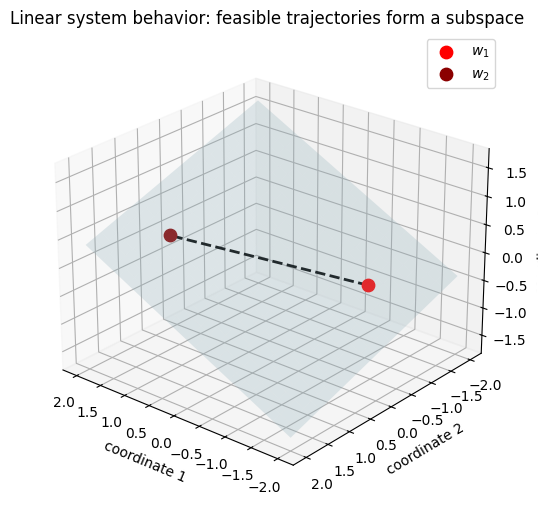

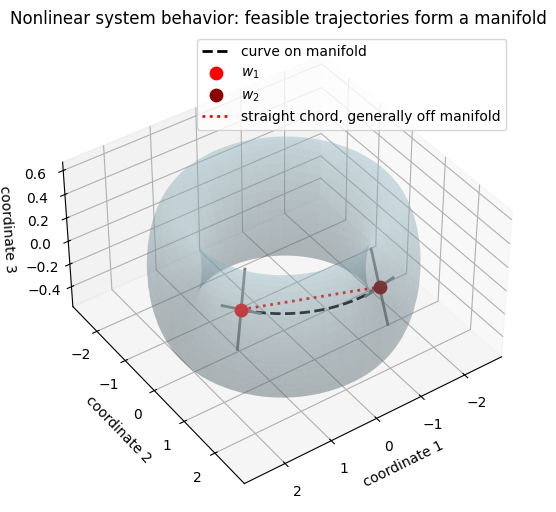

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Plot 1: Linear subspace in R^3
# -----------------------------
fig = plt.figure(figsize=(5, 10))
ax = fig.add_subplot(111, projection="3d")

# Plane: z = 0.5x - 0.3y
x = np.linspace(-2, 2, 25)
y = np.linspace(-2, 2, 25)
X, Y = np.meshgrid(x, y)
Z = 0.5 * X - 0.3 * Y

ax.plot_surface(X, Y, Z, alpha=0.25, color="lightblue", edgecolor="none")

# Two points on the plane
p1 = np.array([-1.2, -0.8, 0.5*(-1.2) - 0.3*(-0.8)])
p2 = np.array([1.3, 0.9, 0.5*(1.3) - 0.3*(0.9)])

# Dashed line connecting them
s = np.linspace(0, 1, 100)
line = (1 - s[:, None]) * p1 + s[:, None] * p2

ax.plot(line[:, 0], line[:, 1], line[:, 2], "k--", linewidth=2)
ax.scatter(*p1, s=80, color="red", label=r"$w_1$")
ax.scatter(*p2, s=80, color="darkred", label=r"$w_2$")

ax.set_title("Linear system behavior: feasible trajectories form a subspace")
ax.set_xlabel("coordinate 1")
ax.set_ylabel("coordinate 2")
ax.set_zlabel("coordinate 3")
ax.legend()
ax.view_init(elev=25, azim=130)
plt.tight_layout()
plt.show()


# -----------------------------
# Plot 2: Nonlinear manifold in R^3: torus
# -----------------------------
fig = plt.figure(figsize=(5, 10))
ax = fig.add_subplot(111, projection="3d")

R = 2.0   # major radius
r = 0.5   # minor radius

u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0, 2*np.pi, 40)
U, V = np.meshgrid(u, v)

X = (R + r*np.cos(V)) * np.cos(U)
Y = (R + r*np.cos(V)) * np.sin(U)
Z = r * np.sin(V)

ax.plot_surface(X, Y, Z, alpha=0.25, color="lightblue", edgecolor="none")

def torus_point(u, v):
    return np.array([
        (R + r*np.cos(v)) * np.cos(u),
        (R + r*np.cos(v)) * np.sin(u),
        r * np.sin(v)
    ])

# Pick two visible points
u1, v1 = 0.65, 0.7
u2, v2 = 1.75, 0.7

p1 = torus_point(u1, v1)
p2 = torus_point(u2, v2)

# Curve on the torus connecting the two points
uu = np.linspace(u1, u2, 100)
vv = np.linspace(v1, v2, 100)
curve = np.array([torus_point(a, b) for a, b in zip(uu, vv)])

ax.plot(curve[:, 0], curve[:, 1], curve[:, 2], "k--", linewidth=2,
        label="curve on manifold")

ax.scatter(*p1, s=80, color="red", label=r"$w_1$")
ax.scatter(*p2, s=80, color="darkred", label=r"$w_2$")

# Tangent directions on torus
def tangent_u(u, v):
    return np.array([
        -(R + r*np.cos(v)) * np.sin(u),
         (R + r*np.cos(v)) * np.cos(u),
         0
    ])

def tangent_v(u, v):
    return np.array([
        -r*np.sin(v) * np.cos(u),
        -r*np.sin(v) * np.sin(u),
         r*np.cos(v)
    ])

for p, uu_, vv_ in [(p1, u1, v1), (p2, u2, v2)]:
    tu = tangent_u(uu_, vv_)
    tv = tangent_v(uu_, vv_)

    tu = tu / np.linalg.norm(tu)
    tv = tv / np.linalg.norm(tv)

    scale = 0.35
    ax.plot(
        [p[0] - scale*tu[0], p[0] + scale*tu[0]],
        [p[1] - scale*tu[1], p[1] + scale*tu[1]],
        [p[2] - scale*tu[2], p[2] + scale*tu[2]],
        color="gray", linewidth=2
    )

    ax.plot(
        [p[0] - scale*tv[0], p[0] + scale*tv[0]],
        [p[1] - scale*tv[1], p[1] + scale*tv[1]],
        [p[2] - scale*tv[2], p[2] + scale*tv[2]],
        color="gray", linewidth=2
    )

# Optional: straight chord to show what would NOT generally lie on manifold
chord = (1 - s[:, None]) * p1 + s[:, None] * p2
ax.plot(chord[:, 0], chord[:, 1], chord[:, 2], "r:", linewidth=2,
        label="straight chord, generally off manifold")

ax.set_title("Nonlinear system behavior: feasible trajectories form a manifold")
ax.set_xlabel("coordinate 1")
ax.set_ylabel("coordinate 2")
ax.set_zlabel("coordinate 3")
ax.legend()
ax.view_init(elev=40, azim=55)
ax.set_box_aspect([1, 1, 0.6])
plt.tight_layout()
plt.show()

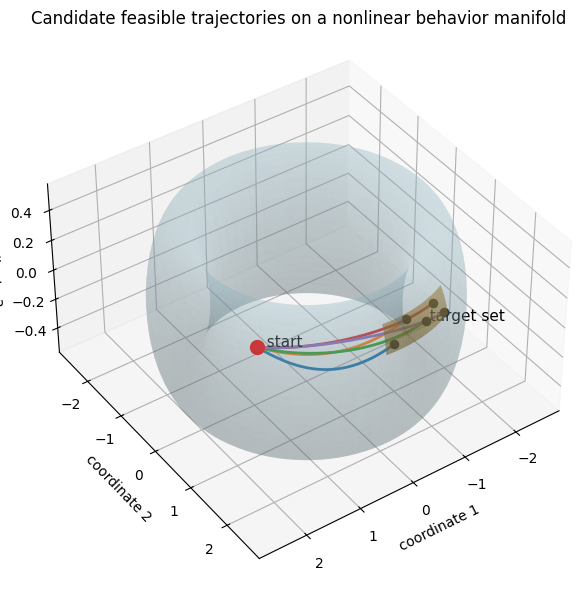

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Torus setup
# -----------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

R = 2.0
r = 0.5

u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, 2*np.pi, 50)
U, V = np.meshgrid(u, v)

X = (R + r*np.cos(V)) * np.cos(U)
Y = (R + r*np.cos(V)) * np.sin(U)
Z = r * np.sin(V)

ax.plot_surface(X, Y, Z, alpha=0.22, color="lightblue", edgecolor="none")

def torus_point(u, v):
    return np.array([
        (R + r*np.cos(v)) * np.cos(u),
        (R + r*np.cos(v)) * np.sin(u),
        r * np.sin(v)
    ])

# Starting trajectory point: previous left point
u_start, v_start = 0.65, 0.7
p_start = torus_point(u_start, v_start)

ax.scatter(*p_start, s=100, color="red")
ax.text(*p_start, "  start", fontsize=11)

# Target region centered near the previous second point
u_target, v_target = 1.75, 0.7
du_region = 0.28
dv_region = 0.22

u_reg = np.linspace(u_target - du_region, u_target + du_region, 25)
v_reg = np.linspace(v_target - dv_region, v_target + dv_region, 25)
Ureg, Vreg = np.meshgrid(u_reg, v_reg)

Xreg = (R + r*np.cos(Vreg)) * np.cos(Ureg)
Yreg = (R + r*np.cos(Vreg)) * np.sin(Ureg)
Zreg = r * np.sin(Vreg)

ax.plot_surface(Xreg, Yreg, Zreg, alpha=0.65, color="orange", edgecolor="none")
ax.text(*torus_point(u_target, v_target), "  target set", fontsize=11)

# Multiple feasible candidate paths on the torus
endpoints = [
    (u_target - 0.22, v_target - 0.12),
    (u_target - 0.10, v_target + 0.14),
    (u_target + 0.05, v_target - 0.05),
    (u_target + 0.15, v_target + 0.10),
    (u_target + 0.24, v_target - 0.15),
]

for i, (u_end, v_end) in enumerate(endpoints):
    s = np.linspace(0, 1, 140)

    # Smooth curves in parameter space.
    # The sinusoidal term creates visibly different candidate trajectories.
    uu = (1 - s) * u_start + s * u_end
    vv = (1 - s) * v_start + s * v_end + 0.18 * np.sin(np.pi * s) * (i - 2) / 2

    path = np.array([torus_point(a, b) for a, b in zip(uu, vv)])

    ax.plot(path[:, 0], path[:, 1], path[:, 2], linewidth=2)
    ax.scatter(*torus_point(u_end, v_end), s=35, color="black")

ax.set_title("Candidate feasible trajectories on a nonlinear behavior manifold")
ax.set_xlabel("coordinate 1")
ax.set_ylabel("coordinate 2")
ax.set_zlabel("coordinate 3")

ax.view_init(elev=40, azim=55)
ax.set_box_aspect([1, 1, 0.6])

plt.tight_layout()
plt.show()